In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [ ]:
!pip uninstall scikit-learn -y

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1


In [ ]:
!pip install scikit-learn==1.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 91.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires 

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/itmo-flat-price-prediction-2025-2026/Archive2025/data.csv')
df_test = pd.read_csv('/content/drive/MyDrive/itmo-flat-price-prediction-2025-2026/Archive2025/test.csv')

In [ ]:
df_train

,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count,price
0,0,17,34,42.876495,Yes,No,Yes,3,1,2011,3.16,12,4,94.876495,2,balcony,Moskovskij,2,28285348
1,1,17,12,25.487543,Yes,Yes,Yes,11,1,1908,4.68,2,2,58.154210,1,balcony,Nevskij,2,12923063
2,2,22,35,39.041948,No,No,Yes,9,1,1953,3.12,3,2,99.041948,2,balcony,Kirovskij,3,20463247
3,3,11,26,11.646696,No,Yes,Yes,5,0,2004,2.50,15,1,50.313363,2,loggia,Krasnoselskij,0,10517141
4,4,8,14,14.406673,No,No,Yes,18,1,1970,2.50,7,2,42.406673,1,balcony,Krasnoselskij,0,8455506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,13,7,12.893951,No,Yes,Yes,5,2,1933,4.26,2,1,34.560618,1,balcony,Petrogradskij,1,9836362
99996,99996,24,15,11.853480,Yes,Yes,Yes,0,1,2001,3.23,9,1,50.853480,1,loggia,Centralnyj,0,13886925
99997,99997,26,30,11.489281,No,No,Yes,14,2,1942,3.22,4,4,72.155948,2,balcony,Vyborgskij,0,15627873
99998,99998,16,36,14.725548,No,No,No,19,0,1911,2.50,2,2,73.058881,2,balcony,Centralnyj,1,17587232


In [ ]:
df_train['district_name'].unique()

array(['Moskovskij', 'Nevskij', 'Kirovskij', 'Krasnoselskij',
       'Vyborgskij', 'Centralnyj', 'Petrogradskij'], dtype=object)

In [ ]:
df_test

,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count
0,0,25,24,11.577599,Yes,Yes,Yes,15,1,1945,2.70,4,2,65.577599,2,balcony,Centralnyj,0
1,1,24,13,28.856040,Yes,Yes,No,13,1,1901,2.50,1,1,70.189373,1,loggia,Kirovskij,2
2,2,14,25,43.275806,Yes,No,Yes,0,1,1941,2.95,3,2,82.275806,2,balcony,Petrogradskij,4
3,3,18,22,11.320209,Yes,Yes,Yes,17,2,1990,3.39,7,2,56.986876,2,loggia,Moskovskij,0
4,4,26,10,20.524394,No,No,Yes,8,1,1938,4.77,3,2,59.191060,1,balcony,Nevskij,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,25,7,17.943718,Yes,No,Yes,6,0,1990,4.03,8,8,51.943718,1,loggia,Centralnyj,0
99996,99996,18,34,11.946184,No,Yes,Yes,19,0,1918,2.88,2,1,70.279518,2,loggia,Vyborgskij,1
99997,99997,12,19,14.405826,No,Yes,Yes,1,1,1944,2.50,4,1,45.739159,2,balcony,Kirovskij,0
99998,99998,14,36,37.533263,No,Yes,Yes,18,0,2012,4.29,12,8,93.533263,2,loggia,Centralnyj,3


In [ ]:
df_test.isnull().sum()

,0
index,0
kitchen_area,0
bath_area,0
other_area,0
gas,0
hot_water,0
central_heating,0
extra_area,0
extra_area_count,0
year,0


In [ ]:
from sklearn import datasets
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_train['year'].corr(df_train['price'])

np.float64(-0.023306753610817656)

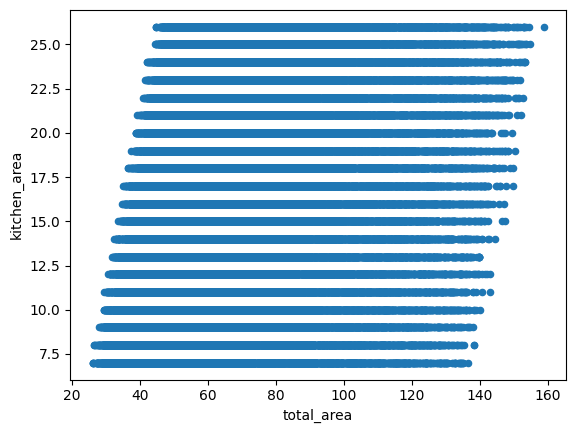

In [ ]:
df_train.plot(kind='scatter',x='total_area',y='kitchen_area')
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import LSTM, Dense,Bidirectional,Dropout, BatchNormalization
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


In [ ]:
df_train.head()

,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count,price
0,0,17,34,42.876495,Yes,No,Yes,3,1,2011,3.16,12,4,94.876495,2,balcony,Moskovskij,2,28285348
1,1,17,12,25.487543,Yes,Yes,Yes,11,1,1908,4.68,2,2,58.154210,1,balcony,Nevskij,2,12923063
2,2,22,35,39.041948,No,No,Yes,9,1,1953,3.12,3,2,99.041948,2,balcony,Kirovskij,3,20463247
3,3,11,26,11.646696,No,Yes,Yes,5,0,2004,2.50,15,1,50.313363,2,loggia,Krasnoselskij,0,10517141
4,4,8,14,14.406673,No,No,Yes,18,1,1970,2.50,7,2,42.406673,1,balcony,Krasnoselskij,0,8455506


In [ ]:
df_train.head()

,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count,price
0,0,17,34,42.876495,Yes,No,Yes,3,1,2011,3.16,12,4,94.876495,2,balcony,Moskovskij,2,28285348
1,1,17,12,25.487543,Yes,Yes,Yes,11,1,1908,4.68,2,2,58.154210,1,balcony,Nevskij,2,12923063
2,2,22,35,39.041948,No,No,Yes,9,1,1953,3.12,3,2,99.041948,2,balcony,Kirovskij,3,20463247
3,3,11,26,11.646696,No,Yes,Yes,5,0,2004,2.50,15,1,50.313363,2,loggia,Krasnoselskij,0,10517141
4,4,8,14,14.406673,No,No,Yes,18,1,1970,2.50,7,2,42.406673,1,balcony,Krasnoselskij,0,8455506


In [ ]:
numerical_features = ['kitchen_area','bath_area','other_area','extra_area','extra_area_count','year','ceil_height','floor_max','floor','total_area','bath_count','rooms_count']

In [ ]:
target = df_train['price']

In [ ]:
categorical_features = ['gas','hot_water','central_heating','extra_area_type_name','district_name']

In [ ]:
for col in numerical_features + categorical_features:
    if col not in df_train.columns:
        df_train[col] = np.nan
    if col not in df_test.columns:
        df_test[col] = np.nan


In [ ]:
# model = Sequential()
# model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(X_train.shape[1], 1)))
# model.add(Dropout(0.2))
# model.add(Bidirectional(LSTM(128, return_sequences=True)))
# model.add(Dropout(0.2))
# model.add(Dense(25))
# model.add(Dense(1))
# model.compile(optimizer='adam', loss='mean_absolute_error')
# model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))
# y_pred = model.predict(X_test)

In [ ]:
# model = GradientBoostingRegressor(n_estimators=200,min_samples_split=3,min_samples_leaf=2)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

In [ ]:
df_train

,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count,price
0,0,17,34,42.876495,Yes,No,Yes,3,1,2011,3.16,12,4,94.876495,2,balcony,Moskovskij,2,28285348
1,1,17,12,25.487543,Yes,Yes,Yes,11,1,1908,4.68,2,2,58.154210,1,balcony,Nevskij,2,12923063
2,2,22,35,39.041948,No,No,Yes,9,1,1953,3.12,3,2,99.041948,2,balcony,Kirovskij,3,20463247
3,3,11,26,11.646696,No,Yes,Yes,5,0,2004,2.50,15,1,50.313363,2,loggia,Krasnoselskij,0,10517141
4,4,8,14,14.406673,No,No,Yes,18,1,1970,2.50,7,2,42.406673,1,balcony,Krasnoselskij,0,8455506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,13,7,12.893951,No,Yes,Yes,5,2,1933,4.26,2,1,34.560618,1,balcony,Petrogradskij,1,9836362
99996,99996,24,15,11.853480,Yes,Yes,Yes,0,1,2001,3.23,9,1,50.853480,1,loggia,Centralnyj,0,13886925
99997,99997,26,30,11.489281,No,No,Yes,14,2,1942,3.22,4,4,72.155948,2,balcony,Vyborgskij,0,15627873
99998,99998,16,36,14.725548,No,No,No,19,0,1911,2.50,2,2,73.058881,2,balcony,Centralnyj,1,17587232


In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
import warnings

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
warnings.filterwarnings('ignore')
import numpy as np
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('to_string', FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_val, y_train, y_val = train_test_split(df_train[numerical_features + categorical_features], target)

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor, VotingRegressor, StackingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, Lasso
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', RandomForestRegressor(n_estimators=50,min_samples_split=2))
# ])

In [ ]:
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', xgb.XGBRegressor(n_estimators=5000,min_samples_split=6,learning_rate=0.04))
# ])

In [ ]:
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', HistGradientBoostingRegressor(max_iter=9000,learning_rate=0.01,max_depth=6,random_state=42))
# ])

In [ ]:
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', Lasso(alpha=2))
# ])

In [ ]:
# estimators = [
#     ('rf', RandomForestRegressor(n_estimators=200,min_samples_split=6,random_state=42,n_jobs=-1)),
#     ('gb', HistGradientBoostingRegressor(max_iter=9000,learning_rate=0.01,max_depth=6,random_state=42)),
#     ('xgb', xgb.XGBRegressor(n_estimators=5000,min_samples_split=6,learning_rate=0.04))
# ]

In [ ]:
# model = StackingRegressor(estimators=estimators,final_estimator=HistGradientBoostingRegressor(max_iter=9000,learning_rate=0.01,max_depth=6,random_state=42))

In [ ]:
# model.fit(X_train, y_train)
# y_pred = model.predict(X_val)

In [ ]:
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', StackingRegressor(estimators=estimators, final_estimator=HistGradientBoostingRegressor(max_iter=9000, learning_rate=0.01, max_depth=6, random_state=42)))
# ])

# model.fit(X_train, y_train)
# y_pred = model.predict(X_val)
# y_test = model.predict(df_test[numerical_features + categorical_features])

In [ ]:
y_test

array([17938528.76199479, 13126791.79077916, 22970018.85494901, ...,
        9463075.68644514, 24650985.9643315 , 26961083.16741702])

In [ ]:
score = mean_absolute_error(y_val, y_pred)
print(f"Mean Absolute Error: {score}")#140525.23073245137,140078.0307793486,139727.46787543932,139719.21007330713 169382.2804579416
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 385501.2056052165
Root Mean Squared Error: 504254.0593188552


In [ ]:
r2_score(y_val, y_pred)

0.9971822133227426

In [ ]:
import pickle

In [ ]:
def to_string_func(x):
    return x.astype(str)

categorical_transformer = Pipeline(steps=[
    ('to_string', FunctionTransformer(to_string_func, validate=False)),
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestRegressor(n_estimators=50,max_depth=10,random_state=42,n_jobs=-1))
])

model.fit(X_train, y_train)

pickle.dump(model, open('new_model.pkl', 'wb'))

In [ ]:
y_test = model.predict(df_test[numerical_features + categorical_features])

In [ ]:
y_pred = model.predict(X_val)

In [ ]:
pickled = pickle.load(open('new_model.pkl', 'rb'))

In [ ]:
r2_score(y_val, y_pred)

0.9927865955210436

In [ ]:
pickled.predict(df_test[numerical_features + categorical_features])

array([17914721.58457923, 13181086.07247334, 23008246.6509539 , ...,
        9421138.0177814 , 24810581.3549697 , 26710353.31968296])

In [ ]:
df_train.head()

,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count,price
0,0,17,34,42.876495,Yes,No,Yes,3,1,2011,3.16,12,4,94.876495,2,balcony,Moskovskij,2,28285348
1,1,17,12,25.487543,Yes,Yes,Yes,11,1,1908,4.68,2,2,58.154210,1,balcony,Nevskij,2,12923063
2,2,22,35,39.041948,No,No,Yes,9,1,1953,3.12,3,2,99.041948,2,balcony,Kirovskij,3,20463247
3,3,11,26,11.646696,No,Yes,Yes,5,0,2004,2.50,15,1,50.313363,2,loggia,Krasnoselskij,0,10517141
4,4,8,14,14.406673,No,No,Yes,18,1,1970,2.50,7,2,42.406673,1,balcony,Krasnoselskij,0,8455506


In [ ]:
categorical_transformer.fit_transform(df_train[categorical_features])


array([[1., 0., 1., 0., 3.],
       [1., 1., 1., 0., 4.],
       [0., 0., 1., 0., 1.],
       ...,
       [0., 0., 1., 0., 6.],
       [0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1.]])

In [ ]:
numerical_features+categorical_features

['kitchen_area',
 'bath_area',
 'other_area',
 'extra_area',
 'extra_area_count',
 'year',
 'ceil_height',
 'floor_max',
 'floor',
 'total_area',
 'bath_count',
 'rooms_count',
 'gas',
 'hot_water',
 'central_heating',
 'extra_area_type_name',
 'district_name']

In [ ]:
submission = pd.read_csv('/content/drive/MyDrive/itmo-flat-price-prediction-2025-2026/Archive2025/solution_example_full.csv')

In [ ]:
submission.head()

,index,price
0,0,28285348
1,1,12923063
2,2,20463247
3,3,10517141
4,4,8455506


In [ ]:
submission['price'] = y_test

In [ ]:
submit = submission.to_csv('submission_flat_price31.csv', index=False)

In [ ]:
import sklearn
print(sklearn.__version__)

1.3.2
